# Varaince Swap Chain
Below is the price chain for Variance swaps, these prices are derived from the market and do not attempt to represent a structuring desk quoting a price, more sophisticated volatility modelling is required, which I am studying towards learning. In this file it contains the documentation of theory and code behind pricing variance swaps, DOCUMENTATION LINK.

In [7]:
import matplotlib.pyplot as plt
import pandas as pd   
import yfinance as yf
import numpy as np
import pickle

In [8]:
vix  = yf.download("^VIX", start='2026-01-19')
vix_prices = vix["Close"].squeeze()
with open("new_variance_swap_prices.pkl", "rb") as f:
    options_chain_data = pickle.load(f)

[*********************100%***********************]  1 of 1 completed


In [9]:
var_swap_price_vol = options_chain_data["var_swap_price_vol"]
var_swap_price_vol_bid = options_chain_data["Bid In Vol"]
var_swap_price_vol_ask = options_chain_data["Ask In Vol"]
vega_notional_rounded = options_chain_data["Vega Notional"]
forward_var_surface = options_chain_data["forward_var_surface"]

<Axes: title={'center': 'Forward Vol'}, xlabel='expiry'>

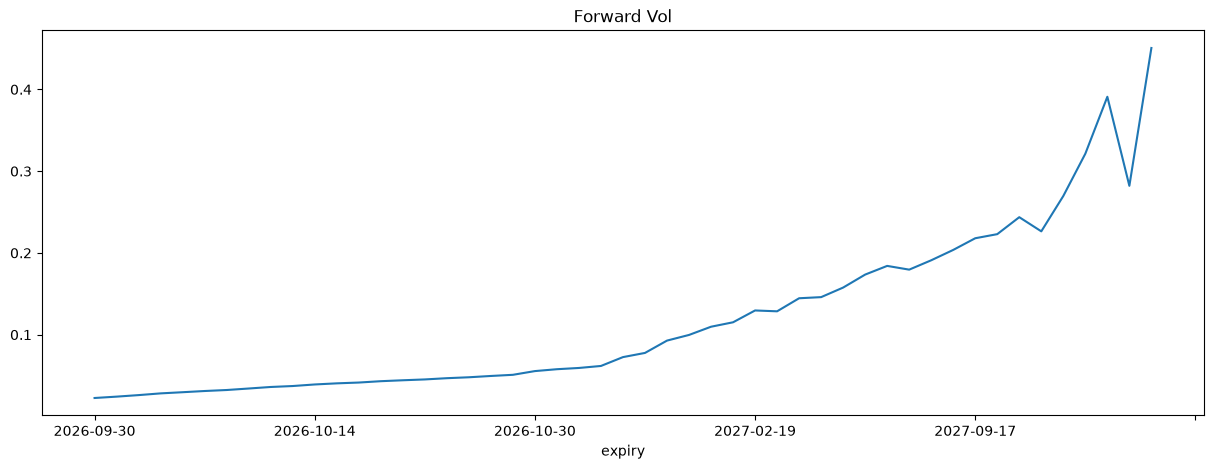

In [10]:
var_swap_price_vol.plot(figsize=(15,5), title='Forward Vol')

Date
2026-01-20    0.2009
2026-01-21    0.1690
2026-01-22    0.1564
2026-01-23    0.1609
2026-01-26    0.1615
               ...  
2026-09-14    0.1710
2026-09-15    0.1720
2026-09-16    0.1771
2026-09-17    0.1544
2026-09-18    0.1481
Name: ^VIX, Length: 170, dtype: float64


<Axes: xlabel='Date'>

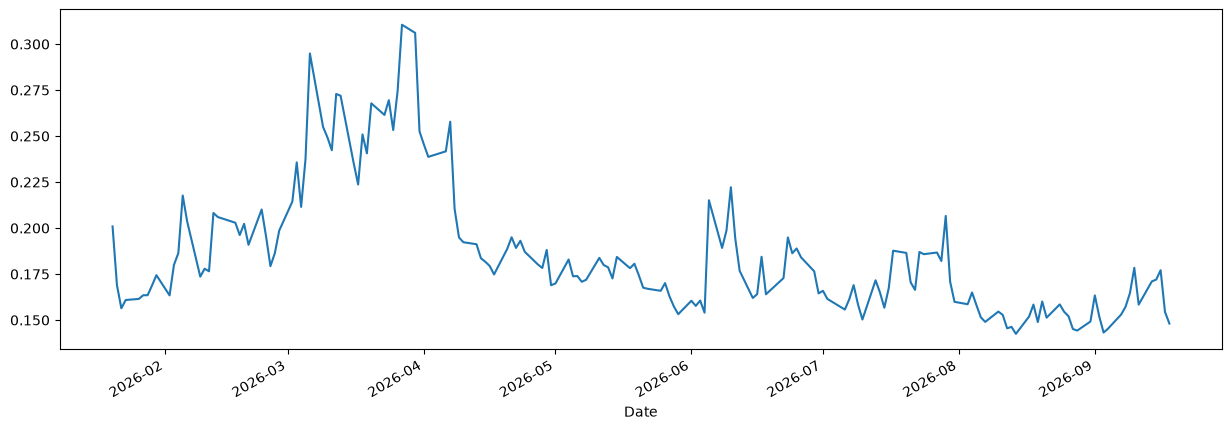

In [11]:
K_var = (vix_prices / 100) 
print(K_var)
K_var.plot(figsize=(15,5))

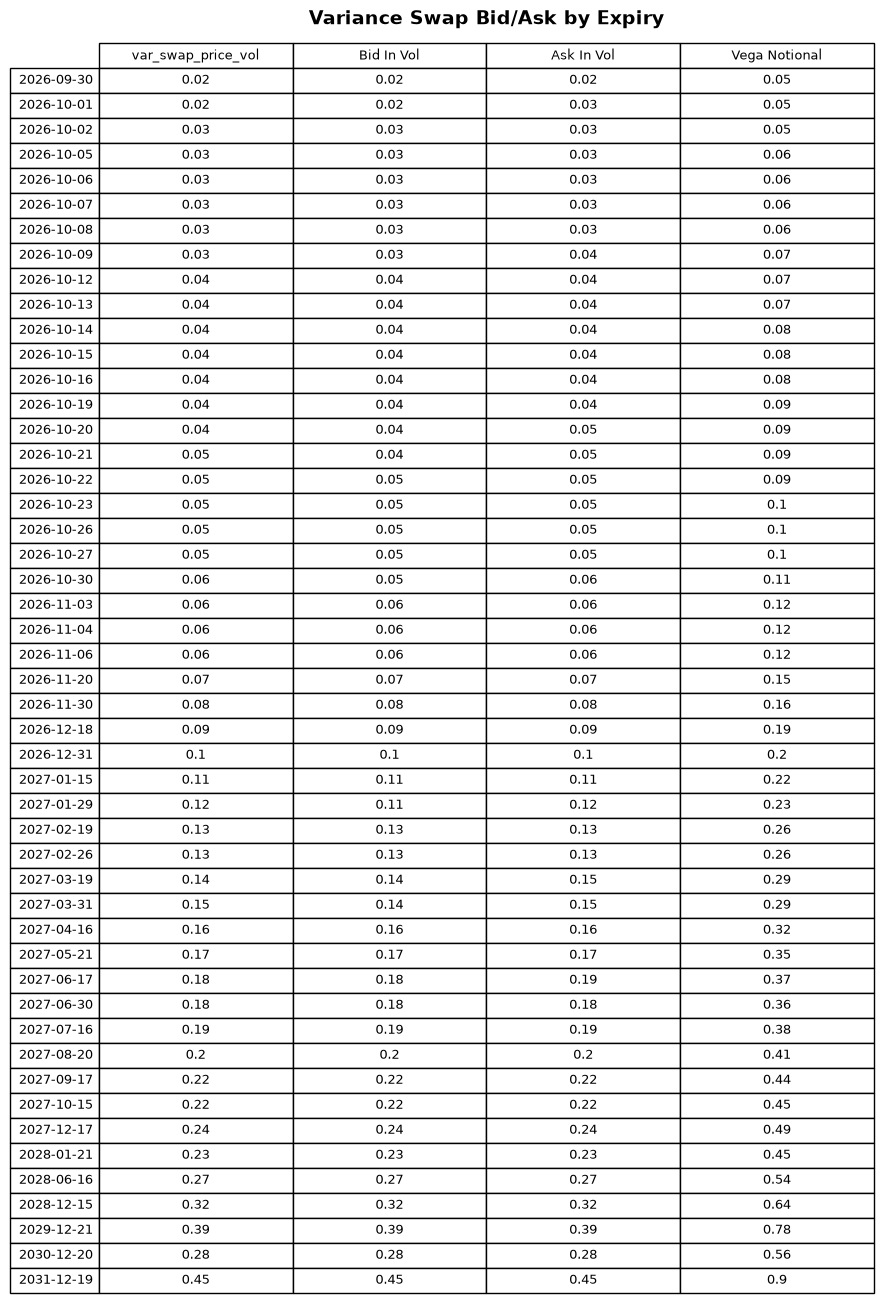

In [14]:
data_V_swap = {
   "var_swap_price_vol": var_swap_price_vol,
    "Bid In Vol": var_swap_price_vol_bid,
    "Ask In Vol": var_swap_price_vol_ask,
    "Vega Notional": vega_notional_rounded,
    
}


data = pd.DataFrame(data_V_swap)
display_data = data.copy()
#display_data["Vega Notional"] = display_data["Vega Notional"].map("${:,.0f}".format)
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")
ax.set_title("Variance Swap Bid/Ask by Expiry", fontsize=14, fontweight="bold", pad=20, y=2.5)
tbl = ax.table(cellText=display_data.round(2).values,
                colLabels=display_data.columns,
                rowLabels=display_data.index,
                loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)
plt.show()